# processing large ensembles

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
# import matplotlib.pyplot as plt
# from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
# import matplotlib as mpl
# import matplotlib.ticker as mticker
import netCDF4
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from cartopy.util import add_cyclic_point
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
# from dask.distributed import Client
# client = Client(n_workers=4, threads_per_worker=2)
# client

In [4]:
from scipy import stats

In [5]:
# mpl.rcParams['font.family'] = 'Droid Sans'
# mpl.rcParams['font.size'] = 12
# # Edit axes parameters
# mpl.rcParams['axes.linewidth'] = 1.5
# # Tick properties
# mpl.rcParams['xtick.major.size'] = 5
# mpl.rcParams['xtick.minor.size'] = 3
# mpl.rcParams['xtick.major.width'] = 1
# mpl.rcParams['xtick.direction'] = 'out'
# mpl.rcParams['ytick.major.size'] = 5
# mpl.rcParams['ytick.minor.size'] = 3
# mpl.rcParams['ytick.major.width'] = 1
# mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [6]:
from functions import preproc_funcs as funcs

In [7]:
from functions import xr_lowess

In [8]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [9]:
import glob
import multiprocessing as mp

In [10]:
# Function to find the first file in each model's r1* directory
def find_all_files(pattern):
    all_paths = sorted(glob.glob(pattern))
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        # model_identifier = path_parts[6] + '_' + path_parts[8][:-1]
        model_identifier = path_parts[8] + '_' + path_parts[10][:-1]
        if model_identifier not in model_files:
            model_files[model_identifier] = '/'.join(path_parts[:-1]) + '/*.nc'  # Store only the first file for each model
    return model_files

## find the files for a single model

In [11]:
model = 'ACCESS-ESM1-5'

In [12]:
ts_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/ts/gn/*/*.nc'
ts_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/ts/gn/*/*.nc'


In [13]:
co2_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/co2/gn/*/*.nc'
co2_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/co2/gn/*/*.nc'

In [14]:
pr_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/pr/gn/*/*.nc'
pr_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/pr/gn/*/*.nc'

In [15]:
psl_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/psl/gn/*/*.nc'
psl_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/psl/gn/*/*.nc'

In [16]:
uas_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/uas/gn/*/*.nc'
uas_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/uas/gn/*/*.nc'

In [17]:
vas_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/vas/gn/*/*.nc'
vas_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/vas/gn/*/*.nc'

In [18]:
tauu_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/tauu/gn/*/*.nc'
tauu_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/tauu/gn/*/*.nc'

In [19]:
thetao_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/thetao/gn/*/*.nc'
thetao_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/thetao/gn/*/*.nc'

In [20]:
msftbarot_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/msftbarot/gn/*/*.nc'
msftbarot_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/msftbarot/gn/*/*.nc'

In [21]:
msftmz_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/msftmz/gn/*/*.nc'
msftmz_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/msftmz/gn/*/*.nc'

In [22]:
htovovrt_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/htovovrt/gn/*/*.nc'
htovovrt_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/htovovrt/gn/*/*.nc'

In [23]:
htovgyre_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/htovgyre/gn/*/*.nc'
htovgyre_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/htovgyre/gn/*/*.nc'

In [155]:
siextentn_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/SImon/siextentn/gn/*/*.nc'
siextentn_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/SImon/siextentn/gn/*/*.nc'

In [156]:
siextents_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/SImon/siextents/gn/*/*.nc'
siextents_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/SImon/siextents/gn/*/*.nc'

In [26]:
ts_files_hist = find_all_files(ts_pattern_hist)
ts_files_ssp5 = find_all_files(ts_pattern_ssp5)

In [27]:
co2_files_hist = find_all_files(co2_pattern_hist)
co2_files_ssp5 = find_all_files(co2_pattern_ssp5)

In [28]:
pr_files_hist = find_all_files(pr_pattern_hist)
pr_files_ssp5 = find_all_files(pr_pattern_ssp5)

In [29]:
psl_files_hist = find_all_files(psl_pattern_hist)
psl_files_ssp5 = find_all_files(psl_pattern_ssp5)

In [30]:
uas_files_hist = find_all_files(uas_pattern_hist)
uas_files_ssp5 = find_all_files(uas_pattern_ssp5)

In [31]:
vas_files_hist = find_all_files(vas_pattern_hist)
vas_files_ssp5 = find_all_files(vas_pattern_ssp5)

In [32]:
tauu_files_hist = find_all_files(tauu_pattern_hist)
tauu_files_ssp5 = find_all_files(tauu_pattern_ssp5)

In [33]:
thetao_files_hist = find_all_files(thetao_pattern_hist)
thetao_files_ssp5 = find_all_files(thetao_pattern_ssp5)

In [34]:
msftbarot_files_hist = find_all_files(msftbarot_pattern_hist)
msftbarot_files_ssp5 = find_all_files(msftbarot_pattern_ssp5)

In [35]:
msftmz_files_hist = find_all_files(msftmz_pattern_hist)
msftmz_files_ssp5 = find_all_files(msftmz_pattern_ssp5)

In [36]:
htovovrt_files_hist = find_all_files(htovovrt_pattern_hist)
htovovrt_files_ssp5 = find_all_files(htovovrt_pattern_ssp5)

In [37]:
htovgyre_files_hist = find_all_files(htovgyre_pattern_hist)
htovgyre_files_ssp5 = find_all_files(htovgyre_pattern_ssp5)

In [157]:
siextentn_files_hist = find_all_files(siextentn_pattern_hist)
siextentn_files_ssp5 = find_all_files(siextentn_pattern_ssp5)

In [158]:
siextents_files_hist = find_all_files(siextents_pattern_hist)
siextents_files_ssp5 = find_all_files(siextents_pattern_ssp5)

In [40]:
import xesmf as xe

In [41]:
# temp_hist = xr.open_dataset(ts_files_hist['ACCESS-CM2'])
# temp_hist

In [42]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset>
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 -90.0 -88.5 -88.5 ... 88.5 90.0

In [43]:
from dask.diagnostics import ProgressBar

In [44]:
# global_regridder = xe.Regridder(xc.open_mfdataset(uas_files_hist['ACCESS-ESM1-5_r10i1p1f']).load(), ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
# global_regridder

In [180]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # Load datasets
        var_file_hist = siextentn_files_hist[model_identifier] # change here
        var_file_ssp = siextentn_files_ssp5[model_identifier] # change here
        ds_var_hist = xc.open_mfdataset(var_file_hist, use_cftime=True).sel(time = slice('1850-01-01', '2015-01-01'))
        ds_var_ssp = xc.open_mfdataset(var_file_ssp, use_cftime=True)
        # add custom time ranges
        ds_var_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_end_year = int(ds_var_ssp.time.dt.year[-1])
        ds_var_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        combined = xr.concat([ds_var_hist, ds_var_ssp], dim='time')
        # regridder = xe.Regridder(combined, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        #
        # with ProgressBar():
        # var = regridder(combined.msftmz.resample(time = 'AS-JUN').mean('time')).load()  # change here
        var = (combined.siextentn.resample(time = 'AS-JUN').mean('time')).load()  # change here
        return model_identifier, var
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")


In [181]:
models_to_process = [(model) for model in siextentn_files_hist if model in siextentn_files_ssp5]
models_to_process

['ACCESS-ESM1-5_r10i1p1f',
 'ACCESS-ESM1-5_r1i1p1f',
 'ACCESS-ESM1-5_r2i1p1f',
 'ACCESS-ESM1-5_r3i1p1f',
 'ACCESS-ESM1-5_r4i1p1f',
 'ACCESS-ESM1-5_r5i1p1f',
 'ACCESS-ESM1-5_r6i1p1f',
 'ACCESS-ESM1-5_r7i1p1f',
 'ACCESS-ESM1-5_r8i1p1f',
 'ACCESS-ESM1-5_r9i1p1f']

In [182]:
# res_arr = []

# for i, model_identifier in enumerate(models_to_process):
#     _, out = process_model(models_to_process[i])
#     res_arr.append((model_identifier, out))
#     print(f'Completed {i+1}')

In [183]:
# Run multiprocessing and gather results
res_arr = []
# with mp.Pool(processes=mp.cpu_count()) as pool:
with mp.Pool(processes=4) as pool:
    i = 0
    for res in pool.imap(process_model, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



In [184]:
model_list = np.array(res_arr)[:, 0]
model_list

array(['ACCESS-ESM1-5_r10i1p1f', 'ACCESS-ESM1-5_r1i1p1f',
       'ACCESS-ESM1-5_r2i1p1f', 'ACCESS-ESM1-5_r3i1p1f',
       'ACCESS-ESM1-5_r4i1p1f', 'ACCESS-ESM1-5_r5i1p1f',
       'ACCESS-ESM1-5_r6i1p1f', 'ACCESS-ESM1-5_r7i1p1f',
       'ACCESS-ESM1-5_r8i1p1f', 'ACCESS-ESM1-5_r9i1p1f'], dtype=object)

In [185]:
res_arr

[('ACCESS-ESM1-5_r10i1p1f',
  <xarray.DataArray 'siextentn' (time: 252)>
  array([15.771398 , 12.70216  , 13.371838 , 13.714352 , 12.889226 ,
         13.101571 , 12.90524  , 12.364826 , 11.886559 , 11.928384 ,
         12.032322 , 12.260619 , 12.457271 , 12.310837 , 11.947467 ,
         12.044578 , 12.053786 , 12.069362 , 12.001332 , 12.28605  ,
         12.833257 , 12.660628 , 12.8079405, 12.206784 , 12.111104 ,
         12.073813 , 12.005105 , 11.548264 , 11.768754 , 11.504082 ,
         11.961907 , 11.874846 , 11.87062  , 11.419599 , 11.678097 ,
         12.149658 , 12.1864195, 12.221508 , 11.697208 , 11.771409 ,
         12.059894 , 11.994893 , 12.416058 , 12.366936 , 12.568417 ,
         12.36684  , 12.6142645, 12.462302 , 12.209907 , 12.037647 ,
         12.058232 , 11.983966 , 12.205426 , 12.08468  , 12.397041 ,
         12.595618 , 12.58586  , 12.116226 , 12.684894 , 12.503822 ,
         12.284787 , 12.329357 , 12.172329 , 12.1192465, 12.064259 ,
         12.00747  , 12.101901

In [186]:
model_var = xr.concat(np.array(res_arr)[:, 1], dim=model_list, coords='minimal', compat='override').rename(dict(concat_dim = 'model')).to_dataset(name = 'siextentn')

In [187]:
out = xr.merge([model_var])
out

<xarray.Dataset>
Dimensions:    (time: 252, model: 10)
Coordinates:
  * time       (time) object 1849-06-01 00:00:00 ... 2100-06-01 00:00:00
  * model      (model) object 'ACCESS-ESM1-5_r10i1p1f' ... 'ACCESS-ESM1-5_r9i...
Data variables:
    siextentn  (model, time) float32 15.77 12.7 13.37 ... 3.466 3.28 0.8703

In [188]:
out.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/{model}_ssp5_siextentn.nc')

### run for thetao and processing isotherm data

In [189]:
from numba import njit

def compute_thermocline_dataset(thetao, lev, max_depth=500, smooth_window=3):
    """
    Compute thermocline depth and temperature as a Dataset using Numba-accelerated gradient search.

    Parameters:
    -----------
    thetao : xarray.DataArray
        Potential temperature (time, lev, lat, lon)
    lev : xarray.DataArray
        Depth levels (1D, in meters)
    max_depth : float
        Maximum depth (in meters) to search for thermocline (default = 500 m)

    Returns:
    --------
    xarray.Dataset with:
        - thermocline_depth (time, lat, lon)
        - temp_at_thermocline (time, lat, lon)
    """

    # Ensure lev is increasing with depth
    if not np.all(np.diff(lev) > 0):
        lev = lev[::-1]
        thetao = thetao.sel(lev=lev)

    lev_vals = lev.values.astype(np.float32)

    # Smooth along vertical axis (lev)
    if smooth_window and smooth_window > 1:
        thetao = thetao.rolling(lev=smooth_window, center=True, min_periods=1).mean('lev')

    @njit
    def _find_thermocline(temp_prof, depth_prof, max_depth):
        n = len(temp_prof)
        max_grad = -1.0
        depth_at_max = np.nan
        temp_at_max = np.nan

        for i in range(n - 1):
            z1, z2 = depth_prof[i], depth_prof[i + 1]
            if z1 > max_depth or z2 > max_depth:
                continue

            t1, t2 = temp_prof[i], temp_prof[i + 1]
            if np.isnan(t1) or np.isnan(t2):
                continue

            dz = z2 - z1
            if dz <= 0:
                continue

            dTdz = abs((t2 - t1) / dz)
            if dTdz > max_grad:
                max_grad = dTdz
                depth_at_max = 0.5 * (z1 + z2)
                temp_at_max = 0.5 * (t1 + t2)

        return depth_at_max, temp_at_max

    def wrapper(temp_prof):
        return _find_thermocline(temp_prof, lev_vals, max_depth)

    depth, temp = xr.apply_ufunc(
        wrapper,
        thetao.chunk(dict(lev=-1, time=1, lat=64, lon=64)),
        input_core_dims=[["lev"]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        # dask="allowed",
        output_dtypes=[np.float32, np.float32],
    )

    return xr.Dataset({
        "thermocline_depth": depth.assign_attrs({
            "units": "m",
            "description": f"Depth of max |dT/dz| in upper {max_depth} m"
        }),
        "temp_at_thermocline": temp.assign_attrs({
            "units": thetao.attrs.get("units", "degC"),
            "description": "Temperature at thermocline depth"
        })
    })

In [190]:
def compute_isotherm_depth(thetao, lev, isotherm_temp=20.0, max_depth=500):
    """
    Compute the depth of a specified isotherm (e.g., 20°C) using linear interpolation.

    Parameters:
    -----------
    thetao : xarray.DataArray
        Potential temperature (time, lev, lat, lon)
    lev : xarray.DataArray
        Depth levels (in meters, 1D)
    isotherm_temp : float
        Target temperature for isotherm (default: 20°C)
    max_depth : float
        Maximum search depth (default: 500 m)

    Returns:
    --------
    isotherm_depth : xarray.DataArray (time, lat, lon)
        Depth at which temperature equals the specified isotherm
    """

    # Ensure increasing depth
    if not np.all(np.diff(lev) > 0):
        lev = lev[::-1]
        thetao = thetao.sel(lev=lev)

    lev_vals = lev.values.astype(np.float32)

    # @njit(parallel=False, nogil=True)
    @njit
    def _find_isotherm(temp_prof, depth_prof, T_iso, max_depth):
        n = len(temp_prof)
        for i in range(n - 1):
            z1, z2 = depth_prof[i], depth_prof[i + 1]
            if z1 > max_depth or z2 > max_depth:
                continue

            t1, t2 = temp_prof[i], temp_prof[i + 1]
            if np.isnan(t1) or np.isnan(t2):
                continue

            if (t1 - T_iso) * (t2 - T_iso) <= 0:
                # Crosses isotherm — linear interpolate
                if t2 != t1:
                    frac = (T_iso - t1) / (t2 - t1)
                    return z1 + frac * (z2 - z1)
                else:
                    return 0.5 * (z1 + z2)

        return np.nan

    def wrapper(temp_prof):
        return _find_isotherm(temp_prof, lev_vals, isotherm_temp, max_depth)

    isotherm_depth = xr.apply_ufunc(
        wrapper,
        thetao,
        input_core_dims=[["lev"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        # dask="allowed",
        output_dtypes=[np.float32],
    )

    isotherm_depth.name = f"isotherm_{int(isotherm_temp)}C_depth"
    isotherm_depth.attrs = {
        "units": "m",
        "description": f"Depth of {isotherm_temp}°C isotherm (upper {max_depth}m)"
    }

    return isotherm_depth

In [191]:
test = xr.open_mfdataset(thetao_files_hist['ACCESS-ESM1-5_r10i1p1f']).chunk(dict(time=12, lev=-1, i=64, j=64))
test

<xarray.Dataset>
Dimensions:             (time: 1980, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12...
  * lev                 (lev) float64 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j                   (j) int32 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
  * i                   (i) int32 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
    latitude            (j, i) float64 dask.array<chunksize=(64, 64), meta=np.ndarray>
    longitude           (j, i) float64 dask.array<chunksize=(64, 64), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] dask.array<chunksize=(12, 2), meta=np.ndarray>
    lev_bnds            (time, lev, bnds) float64 dask.array<chunksize=(12, 50, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 dask.array<chunksize=(12, 64, 64, 4), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 dask.array<chunksize=(12, 64, 64, 4), meta=np.ndarray>
    thetao              (time, lev, j, i) float32 dask.array<chunksize=(12, 50, 64, 64), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  91311.0
    creation_date:          2020-07-30T04:35:15Z
    ...                     ...
    variable_id:            thetao
    variant_label:          r10i1p1f1
    version:                v20200730
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/5fc74efd-f9f1-416b-a2d5-e664de7afe60

In [192]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = test['latitude']  # shape: (i, j)
lon = test['longitude']

# Define your region
lat_min, lat_max = -5, 5
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
mask_equatorial_pacific = ((lat >= lat_min) & (lat <= lat_max) &
        (lon >= lon_min) & (lon <= lon_max))

In [193]:
mask_loaded = mask_equatorial_pacific.load()

In [194]:
# test.thetao.isel(time = -1, lev=0).where(mask_loaded, drop=True).plot()

In [195]:

# res_arr = []
# for i, model_identifier in enumerate(models_to_process):
#     try:
#         print(f"Processing {model_identifier} [{i+1}/{len(models_to_process)}]")

#         # Load and process
#         thetao_file_hist = thetao_files_hist[model_identifier]
#         thetao_file_ssp = thetao_files_ssp5[model_identifier]
#         ds_hist = xr.open_mfdataset(thetao_file_hist, use_cftime=True, combine='by_coords', parallel=True).thetao.sel(lev = slice(0, 500))
#         ds_ssp = xr.open_mfdataset(thetao_file_ssp, use_cftime=True, combine='by_coords', parallel=True).thetao.sel(lev = slice(0, 500))
#         ds_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
#         ssp_end_year = int(ds_ssp.time.dt.year[-1])
#         ds_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')

#         # ds_combined = global_regridder(xr.concat([ds_hist, ds_ssp], dim='time')).sel(lat = slice(-25, 25), lon = slice(100, 300))
#         ds_combined = xr.concat([ds_hist, ds_ssp], dim='time')

#         with ProgressBar():
#             thetao_out = ds_combined.resample(time='AS-JUN').mean('time').load()

#         # # Compute thermocline dataset
#         # with ProgressBar():
#         #     t20d = compute_thermocline_dataset(thetao_in.chunk(dict(lev=-1, time=12, lat=64, lon=64)), thetao_in.lev.chunk(dict(lev=-1))).load()

#         res_arr.append((model_identifier, thetao_out))

#     except Exception as e:
#         print(f"Error processing {model_identifier}: {e}")

In [197]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model_for_thetao(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        thetao_file_hist = thetao_files_hist[model_identifier]
        thetao_file_ssp = thetao_files_ssp5[model_identifier]
        ds_thetao_hist = xc.open_mfdataset(thetao_file_hist, use_cftime=True, parallel=True).thetao.sel(time = slice('1850-01-01', '2015-01-01')).sel(lev = slice(0, 400)).chunk(dict(time=12, lev=-1, i=64, j=64)).where(mask_loaded, drop=True)
        ds_thetao_ssp = xc.open_mfdataset(thetao_file_ssp, use_cftime=True, parallel=True).thetao.sel(lev = slice(0, 400)).chunk(dict(time=12, lev=-1, i=64, j=64)).where(mask_loaded, drop=True)

        # add custom time ranges
        # ds_thetao_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        # ssp_end_year = int(ds_thetao_ssp.time.dt.year[-1])
        # ds_thetao_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        combined = xr.concat([ds_thetao_hist, ds_thetao_ssp], dim='time').resample(time = 'AS-JUN').mean('time')
        #
        # with ProgressBar():
        # thetao_regrid = global_regridder(combined.thetao)  # thetao data
        # t20d = (compute_isotherm_depth(combined.chunk(dict(lev=-1, time=12, lat=64, lon=64)), thetao_regrid.lev.chunk(dict(lev=-1)))).load()
        with ProgressBar():
            t20d = (compute_isotherm_depth(combined, combined.lev)).load()

        return model_identifier, t20d
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")

In [198]:
res_arr = []
for i in range(len(models_to_process)):
    res = process_model_for_thetao(models_to_process[i])
    res_arr.append(res)

[########################################] | 100% Completed | 540.79 s
[########                                ] | 22% Completed | 151.09 s


KeyboardInterrupt: 

In [ ]:
res_arr

[('ACCESS-ESM1-5_r27i1p1f',
  <xarray.DataArray 'isotherm_20C_depth' (time: 252, j: 110, i: 200)>
  array([[[ 91.71477 , 105.77987 , 139.68434 , ...,        nan,
                  nan,        nan],
          [110.54527 , 138.12854 , 174.28967 , ...,        nan,
                  nan,        nan],
          [155.60928 , 172.82474 , 185.30249 , ...,        nan,
                  nan,        nan],
          ...,
          [       nan,        nan,        nan, ..., 315.5047  ,
           303.6996  , 290.57742 ],
          [       nan,        nan,        nan, ..., 257.9785  ,
           251.64845 , 248.73776 ],
          [       nan,        nan,        nan, ..., 182.75484 ,
           200.2619  , 212.08414 ]],
  
         [[118.93338 , 140.45238 , 157.70479 , ...,        nan,
                  nan,        nan],
          [153.70483 , 168.40538 , 182.85732 , ...,        nan,
                  nan,        nan],
          [175.5561  , 190.25043 , 203.42346 , ...,        nan,
                  n

In [ ]:
# # Run multiprocessing and gather results
# res_arr = []
# with mp.Pool(processes=2) as pool:
#     i = 0
#     for res in pool.imap(process_model_for_thetao, models_to_process):
#         res_arr.append(res)
#         print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
#         i += 1



In [ ]:
model_list = np.array(res_arr)[:, 0]
model_list

array(['ACCESS-ESM1-5_r27i1p1f', 'ACCESS-ESM1-5_r10i1p1f',
       'ACCESS-ESM1-5_r31i1p1f', 'ACCESS-ESM1-5_r9i1p1f',
       'ACCESS-ESM1-5_r5i1p1f', 'ACCESS-ESM1-5_r26i1p1f',
       'ACCESS-ESM1-5_r11i1p1f', 'ACCESS-ESM1-5_r8i1p1f',
       'ACCESS-ESM1-5_r30i1p1f', 'ACCESS-ESM1-5_r4i1p1f',
       'ACCESS-ESM1-5_r25i1p1f', 'ACCESS-ESM1-5_r29i1p1f',
       'ACCESS-ESM1-5_r33i1p1f', 'ACCESS-ESM1-5_r12i1p1f',
       'ACCESS-ESM1-5_r7i1p1f', 'ACCESS-ESM1-5_r24i1p1f',
       'ACCESS-ESM1-5_r28i1p1f', 'ACCESS-ESM1-5_r32i1p1f',
       'ACCESS-ESM1-5_r13i1p1f', 'ACCESS-ESM1-5_r6i1p1f',
       'ACCESS-ESM1-5_r40i1p1f', 'ACCESS-ESM1-5_r23i1p1f',
       'ACCESS-ESM1-5_r39i1p1f', 'ACCESS-ESM1-5_r1i1p1f',
       'ACCESS-ESM1-5_r18i1p1f', 'ACCESS-ESM1-5_r14i1p1f',
       'ACCESS-ESM1-5_r35i1p1f', 'ACCESS-ESM1-5_r22i1p1f',
       'ACCESS-ESM1-5_r38i1p1f', 'ACCESS-ESM1-5_r19i1p1f',
       'ACCESS-ESM1-5_r15i1p1f', 'ACCESS-ESM1-5_r34i1p1f',
       'ACCESS-ESM1-5_r21i1p1f', 'ACCESS-ESM1-5_r3i1p1f',
     

In [ ]:
model_var = xr.concat(np.array(res_arr)[:, 1], dim=model_list, coords='minimal', compat='override').rename(dict(concat_dim = 'model')).to_dataset(name = 'tcd')

In [ ]:
out = xr.merge([model_var])
out

<xarray.Dataset>
Dimensions:    (j: 110, i: 200, time: 452, model: 40)
Coordinates:
  * j          (j) int32 82 83 84 85 86 87 88 89 ... 185 186 187 188 189 190 191
  * i          (i) int32 20 21 22 23 24 25 26 27 ... 213 214 215 216 217 218 219
  * time       (time) object 1849-06-01 00:00:00 ... 2300-06-01 00:00:00
    latitude   (j, i) float64 -24.6 -24.6 -24.6 -24.6 ... 24.6 24.6 24.6 24.6
    longitude  (j, i) float64 100.5 101.5 102.5 103.5 ... 297.5 298.5 299.5
  * model      (model) object 'ACCESS-ESM1-5_r27i1p1f' ... 'ACCESS-ESM1-5_r17...
Data variables:
    tcda       (model, time, j, i) float32 91.71 105.8 139.7 ... nan nan nan

In [ ]:
out.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/{model}_ssp5_tcd.nc')

In [ ]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = test['latitude']  # shape: (i, j)
lon = test['longitude']

# Define your region
lat_min, lat_max = -80, -40
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
mask_sh_pacific = ((lat >= lat_min) & (lat <= lat_max) &
        (lon >= lon_min) & (lon <= lon_max))

In [ ]:
mask_sh_pacific_loaded = mask_sh_pacific.load()

In [ ]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = test['latitude']  # shape: (i, j)
lon = test['longitude']

# Define your region
lat_min, lat_max = -80, 80
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
mask_zonal_pacific = ((lat >= lat_min) & (lat <= lat_max) &
        (lon >= lon_min) & (lon <= lon_max))

In [ ]:
mask_zonal_pacific_loaded = mask_zonal_pacific.load()

In [ ]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model_for_regional_thetao(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        thetao_file_hist = thetao_files_hist[model_identifier]
        thetao_file_ssp = thetao_files_ssp5[model_identifier]
        ds_thetao_hist = xc.open_mfdataset(thetao_file_hist, use_cftime=True, parallel=True).thetao.sel(time = slice('1850-01-01', '2015-01-01')).sel(lev = slice(0, 2000)).chunk(dict(time=12, lev=-1, i=64, j=64)).where(mask_sh_pacific_loaded, drop=True).mean('j')
        ds_thetao_ssp = xc.open_mfdataset(thetao_file_ssp, use_cftime=True, parallel=True).thetao.sel(lev = slice(0, 2000)).chunk(dict(time=12, lev=-1, i=64, j=64)).where(mask_sh_pacific_loaded, drop=True).mean('j')

        # add custom time ranges
        # ds_thetao_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        # ssp_end_year = int(ds_thetao_ssp.time.dt.year[-1])
        # ds_thetao_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        combined = xr.concat([ds_thetao_hist, ds_thetao_ssp], dim='time').resample(time = 'AS-JUN').mean(('time'))
        #
        # with ProgressBar():
        # thetao_regrid = global_regridder(combined.thetao)  # thetao data
        # t20d = (compute_isotherm_depth(combined.chunk(dict(lev=-1, time=12, lat=64, lon=64)), thetao_regrid.lev.chunk(dict(lev=-1)))).load()
        with ProgressBar():
            thetao_zonal = (combined).load()

        return model_identifier, thetao_zonal
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")

In [204]:
test = xr.open_mfdataset(thetao_files_hist['ACCESS-ESM1-5_r10i1p1f'], parallel=True)
test

<xarray.Dataset>
Dimensions:             (time: 1980, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12...
  * lev                 (lev) float64 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j                   (j) int32 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
  * i                   (i) int32 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
    latitude            (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] dask.array<chunksize=(120, 2), meta=np.ndarray>
    lev_bnds            (time, lev, bnds) float64 dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 dask.array<chunksize=(120, 300, 360, 4), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 dask.array<chunksize=(120, 300, 360, 4), meta=np.ndarray>
    thetao              (time, lev, j, i) float32 dask.array<chunksize=(120, 50, 300, 360), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  91311.0
    creation_date:          2020-07-30T04:35:15Z
    ...                     ...
    variable_id:            thetao
    variant_label:          r10i1p1f1
    version:                v20200730
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/5fc74efd-f9f1-416b-a2d5-e664de7afe60

In [205]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = test['latitude']  # shape: (i, j)
lon = test['longitude']

# Define your region
lat_min, lat_max = -30, 30
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
mask_equatorial_pacific = ((lat >= lat_min) & (lat <= lat_max) &
        (lon >= lon_min) & (lon <= lon_max))

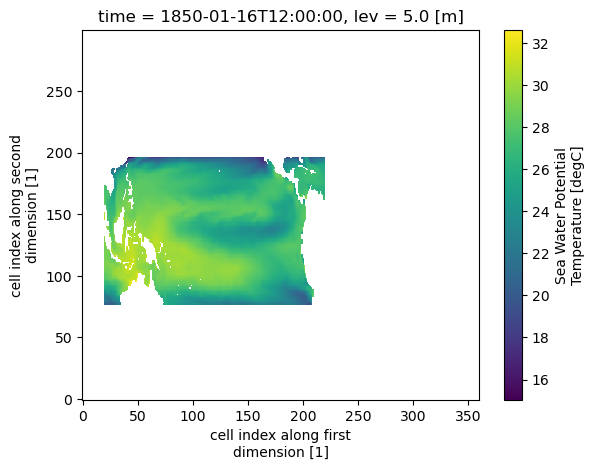

In [207]:
test.thetao.where(mask_equatorial_pacific).isel(lev=0, time=0).plot()